In [59]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import re
import warnings 
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import  (accuracy_score,precision_score,recall_score,f1_score,classification_report,ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow.keras.layers import(Embedding,SimpleRNN,LSTM,GRU,Bidirectional,Dense,Dropout,SpatialDropout1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import (EarlyStopping,ReduceLROnPlateau,ModelCheckpoint)
import  pickle


## IMPORT DATASET 

In [60]:
df1=pd.read_json("Sarcasm_Headlines_Dataset_v2.json",lines=True)

In [61]:
df1.head()

,is_sarcastic,headline,article_link
0,1,thirtysomething scientists unveil doomsday clo...,https://www.theonion.com/thirtysomething-scien...
1,0,dem rep. totally nails why congress is falling...,https://www.huffingtonpost.com/entry/donna-edw...
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-...
3,1,inclement weather prevents liar from getting t...,https://local.theonion.com/inclement-weather-p...
4,1,mother comes pretty close to using word 'strea...,https://www.theonion.com/mother-comes-pretty-c...


In [62]:
df1.duplicated().sum()

np.int64(2)

In [63]:
df1["headline"].duplicated().sum()

np.int64(116)

In [64]:
df1.drop_duplicates(subset="headline",inplace=True)

In [65]:
df1.isnull().sum()

is_sarcastic    0
headline        0
article_link    0
dtype: int64

## TEXT CLEANING MINIMAL (  FOR DEEP LEARNING )

In [66]:
def clean_text(text):
    text= str(text).lower()

    #remove URL
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [67]:
df1["clean_text"]=df1["headline"].apply(clean_text)

In [68]:
df1[["headline","clean_text"]].head(10)

,headline,clean_text
0,thirtysomething scientists unveil doomsday clo...,thirtysomething scientists unveil doomsday clo...
1,dem rep. totally nails why congress is falling...,dem rep. totally nails why congress is falling...
2,eat your veggies: 9 deliciously different recipes,eat your veggies: 9 deliciously different recipes
3,inclement weather prevents liar from getting t...,inclement weather prevents liar from getting t...
4,mother comes pretty close to using word 'strea...,mother comes pretty close to using word 'strea...
5,my white inheritance,my white inheritance
6,5 ways to file your taxes with less stress,5 ways to file your taxes with less stress
7,richard branson's global-warming donation near...,richard branson's global-warming donation near...
8,shadow government getting too large to meet in...,shadow government getting too large to meet in...
9,lots of parents know this scenario,lots of parents know this scenario


## DEFINE X AND Y

In [69]:
X=df1["clean_text"]
y=df1["is_sarcastic"]

In [70]:
print("X_shape",X.shape)
print("y_shape:",y.shape)

X_shape (28503,)
y_shape: (28503,)


In [71]:
## TRAIN TEST SPLIT 

In [72]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [73]:
print("Training Samples:",len(X_train))
print("Testing Samples",len(X_test))

Training Samples: 22802
Testing Samples 5701


In [74]:
print(y_test.value_counts())

is_sarcastic
0    2990
1    2711
Name: count, dtype: int64


## TOKENIZATION

In [75]:
MAX_WORDS=25000
OOV_TOKEN="<OOV>"

In [76]:
tokenizer=Tokenizer(num_words=MAX_WORDS,oov_token=OOV_TOKEN)

In [77]:
tokenizer.fit_on_texts(X_train)

In [78]:
len(tokenizer.word_index)

27642

In [79]:
list(tokenizer.word_index.items())[-50:]

[("92'", 27593),
 ('rodney', 27594),
 ('bungles', 27595),
 ('depends', 27596),
 ('1996', 27597),
 ('reintegration', 27598),
 ('mumolo', 27599),
 ("'bridesmaids'", 27600),
 ("'shithole'", 27601),
 ('tarot', 27602),
 ('pliers', 27603),
 ("present's", 27604),
 ("rogers'", 27605),
 ('gerrymandered', 27606),
 ('jubilee', 27607),
 ('strata', 27608),
 ('merchandise', 27609),
 ("'hold", 27610),
 ('swinging', 27611),
 ('258', 27612),
 ('159', 27613),
 ('mirena', 27614),
 ('intrauterine', 27615),
 ('shredder', 27616),
 ("'suppressed", 27617),
 ("naked'", 27618),
 ('weirder', 27619),
 ('col', 27620),
 ('samsonite', 27621),
 ('lint', 27622),
 ('cardigan', 27623),
 ('admin', 27624),
 ('popped', 27625),
 ('phat', 27626),
 ('jncos', 27627),
 ('riley', 27628),
 ('imagery', 27629),
 ('stitched', 27630),
 ("wino's", 27631),
 ('bronco', 27632),
 ('forgetful', 27633),
 ('respecting', 27634),
 ('thinner', 27635),
 ('401k', 27636),
 ("rex's", 27637),
 ('rotund', 27638),
 ('replaceable', 27639),
 ("dream'", 

In [80]:
X_train.apply(type).value_counts()

clean_text
<class 'str'>    22802
Name: count, dtype: int64

## Convert Text to Sequence

In [81]:
X_train_seq = tokenizer.texts_to_sequences(X_train)

X_test_seq = tokenizer.texts_to_sequences(X_test)

In [82]:
print([X_train.iloc[0],X_train_seq[0]])

["'gobbler games' is the brutal hunger games parody you need to see", [14011, 5450, 11, 4, 4223, 2599, 1486, 2600, 20, 167, 2, 178]]


In [83]:
# analyze sequence length before max_len

In [84]:
seq_analyze=[len(sequence) for sequence in X_train_seq]
max(seq_analyze)

152

In [85]:
min(seq_analyze)

2

In [86]:
pd.Series(seq_analyze).describe(percentiles=[0.90,0.95,0.99])

count    22802.000000
mean        10.269275
std          3.445533
min          2.000000
50%         10.000000
90%         14.000000
95%         16.000000
99%         19.000000
max        152.000000
dtype: float64

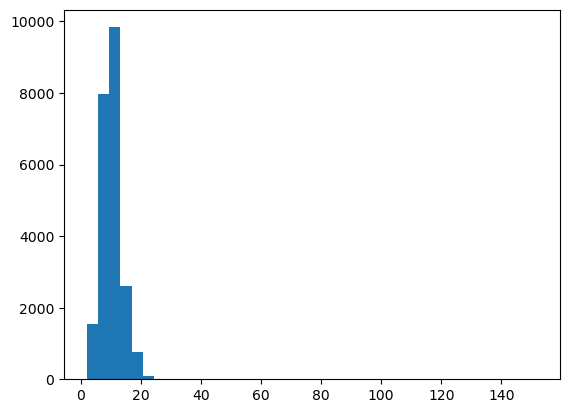

In [87]:
plt.hist( seq_analyze,bins=40)
plt.show()

In [88]:
MAX_LEN= int(np.percentile(seq_analyze,95))
MAX_LEN

16

In [89]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
# PADDING
X_train_pad=pad_sequences(X_train_seq,maxlen=MAX_LEN,padding="post",truncating="post")
X_test_pad=pad_sequences(X_test_seq,maxlen=MAX_LEN,padding="post",truncating="post")

In [90]:
# check shape after padding 
print("Train_shape",X_train_pad.shape)
print("Test Shape",X_test_pad.shape)

Train_shape (22802, 16)
Test Shape (5701, 16)


## Define EVALUATION FUNCTION

In [91]:
results2=[]

def evaluation_model(model,model_name,x_test,x_train,y_test,y_train,thersold=0.5):
    # predict probablities
    y_prob_test=model.predict(x_test,verbose=0).ravel()
    y_prob_train=model.predict(x_train,verbose=0).ravel()
    

    #convert probablities into labels
    y_pred_test=(y_prob_test>=thersold).astype(int)
    y_pred_train=(y_prob_train>=thersold).astype(int)

    #claculate metrics
    accuracy_test=accuracy_score(y_test,y_pred_test)
    accuracy_train=accuracy_score(y_train,y_pred_train)

    #recall
    recall=recall_score(y_test,y_pred_test,zero_division=0)

    print( f"MODEL :{model_name}")
    print(f"TEST_ACCURACY:{accuracy_test:.4f}")
    print(f"TRAIN_ACCURACY:{accuracy_train:.4f}")
    print(f"RECALL :{recall:.4f}")

    print("\nClassification_Report\n")
    print(classification_report(y_test,y_pred_test,digits=4,zero_division=0))

    # confusion matrix display 
    ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test,cmap="Blues")
    plt.title(f"Confusion Matrix :{model_name}")
    plt.show()

    return { "Model":model_name,"Train_accuracy":accuracy_train,"Test_Accuracy":accuracy_test,"Recall":recall}


In [92]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding,SpatialDropout1D,SimpleRNN,Dense,Dropout)

## MODELLING

#### 1.  SIMPLE RNN

In [93]:
rnn_model= Sequential()

#EMBEDDING
rnn_model.add(Embedding(input_dim= MAX_WORDS,output_dim=128,mask_zero=True))

#Spatial Dropout
rnn_model.add(SpatialDropout1D(0.2))

#SimpleRNN
rnn_model.add(SimpleRNN(units=64,dropout=0.2,recurrent_dropout=0.2))

#Dense Layer
rnn_model.add(Dense(units=64,activation="relu"))

#DROPOUT
rnn_model.add(Dropout(0.2))

#OUTPUT LAYER 
rnn_model.add(Dense(units=1,activation="sigmoid"))

In [94]:
rnn_model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [95]:
rnn_model.build(input_shape=(None,MAX_LEN))
rnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 16, 128)        │     3,200,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 16, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,216,577 (12.27 MB)

 Trainable params: 3,216,577 (12.27 MB)

 Non-trainable params: 0 (0.00 B)

In [96]:
#model train 
rnn_history=rnn_model.fit(X_train_pad,y_train,validation_split=0.2,epochs=15,batch_size=64,verbose=1)

Epoch 1/15
286/286 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.7287 - loss: 0.5224 - val_accuracy: 0.8459 - val_loss: 0.3678
Epoch 2/15
286/286 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.8986 - loss: 0.2673 - val_accuracy: 0.8364 - val_loss: 0.3699
Epoch 3/15
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.9517 - loss: 0.1404 - val_accuracy: 0.8432 - val_loss: 0.4643
Epoch 4/15
286/286 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.9746 - loss: 0.0723 - val_accuracy: 0.8301 - val_loss: 0.5381
Epoch 5/15
286/286 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.9854 - loss: 0.0427 - val_accuracy: 0.8316 - val_loss: 0.6592
Epoch 6/15
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.9913 - loss: 0.0290 - val_accuracy: 0.8275 - val_loss: 0.7675
Epoch 7/15
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.9934 - loss: 0.0203 - val_accuracy: 0.8277 - val_loss: 0.8574
Epoch 8/15
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.9919 - loss: 0.0243 - 

MODEL :Simple-RNN
TEST_ACCURACY:0.8306
TRAIN_ACCURACY:0.9642
RECALL :0.8152

Classification_Report

              precision    recall  f1-score   support

           0     0.8344    0.8445    0.8394      2990
           1     0.8262    0.8152    0.8206      2711

    accuracy                         0.8306      5701
   macro avg     0.8303    0.8298    0.8300      5701
weighted avg     0.8305    0.8306    0.8305      5701



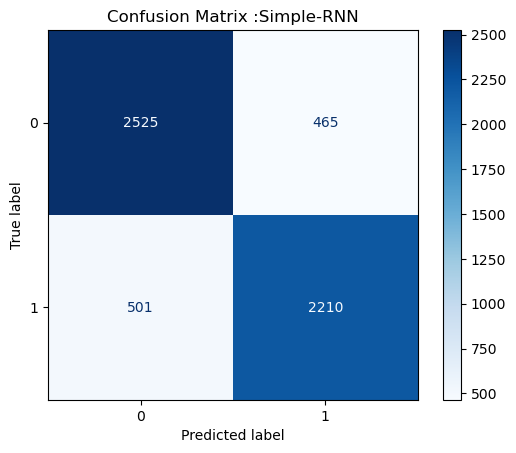

In [97]:
rnn_results=evaluation_model(rnn_model,"Simple-RNN",X_test_pad,X_train_pad,y_test,y_train)
results2.append(rnn_results)

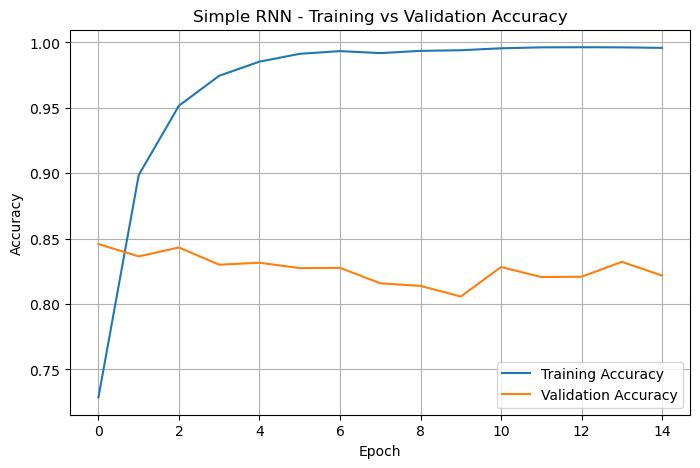

In [98]:
#Training Accurcay VS VALIDATION ACCURACY GRAPH
plt.figure(figsize=(8, 5))

plt.plot(rnn_history.history["accuracy"],label="Training Accuracy")
plt.plot(rnn_history.history["val_accuracy"],label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Simple RNN - Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

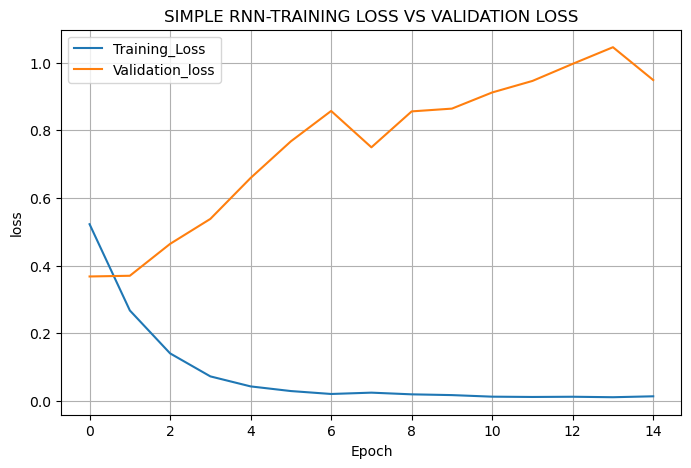

In [99]:
#Training LOSS VS VALIDATION LOSS GRAPH 

plt.figure(figsize=(8,5))

plt.plot(rnn_history.history["loss"],label="Training_Loss")
plt.plot(rnn_history.history["val_loss"],label="Validation_loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.title("SIMPLE RNN-TRAINING LOSS VS VALIDATION LOSS")
plt.legend()
plt.grid()
plt.show()
          

In [100]:
from tensorflow.keras.layers import Input

#### 2.LSTM

In [101]:
lstm_model=Sequential()
# Input
lstm_model.add(Input(shape=(MAX_LEN,)))

# embedding 
lstm_model.add(Embedding(input_dim=MAX_WORDS,output_dim=128,mask_zero=True))

# Dropout
lstm_model.add(SpatialDropout1D(0.2))

#LSTM MODEL
lstm_model.add(LSTM(units=64,dropout=0.2,recurrent_dropout=0.2))

#Hidden Layer
lstm_model.add(Dense(units=64,activation='relu'))

#Dropout
lstm_model.add(Dropout(0.3))

# Output Layer
lstm_model.add(Dense(units=1,activation='sigmoid'))



In [102]:
lstm_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [103]:
lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 16, 128)        │     3,200,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 16, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,253,633 (12.41 MB)

 Trainable params: 3,253,633 (12.41 MB)

 Non-trainable params: 0 (0.00 B)

In [104]:
lstm_history=lstm_model.fit(X_train_pad,y_train,validation_split=0.2,epochs=20,batch_size=64,verbose=1)

Epoch 1/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.7924 - loss: 0.4291 - val_accuracy: 0.8487 - val_loss: 0.3351
Epoch 2/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - accuracy: 0.9243 - loss: 0.1968 - val_accuracy: 0.8465 - val_loss: 0.3622
Epoch 3/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.9707 - loss: 0.0852 - val_accuracy: 0.8406 - val_loss: 0.4698
Epoch 4/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - accuracy: 0.9858 - loss: 0.0416 - val_accuracy: 0.8345 - val_loss: 0.5874
Epoch 5/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - accuracy: 0.9916 - loss: 0.0244 - val_accuracy: 0.8294 - val_loss: 0.6767
Epoch 6/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - accuracy: 0.9959 - loss: 0.0136 - val_accuracy: 0.8312 - val_loss: 0.8518
Epoch 7/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.9959 - loss: 0.0123 - val_accuracy: 0.8264 - val_loss: 0.8929
Epoch 8/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - accuracy: 0.9981 - loss: 0.0070 - 

MODEL :Simple-LSTM
TEST_ACCURACY:0.8306
TRAIN_ACCURACY:0.9652
RECALL :0.8122

Classification_Report

              precision    recall  f1-score   support

           0     0.8327    0.8472    0.8399      2990
           1     0.8281    0.8122    0.8201      2711

    accuracy                         0.8306      5701
   macro avg     0.8304    0.8297    0.8300      5701
weighted avg     0.8305    0.8306    0.8305      5701



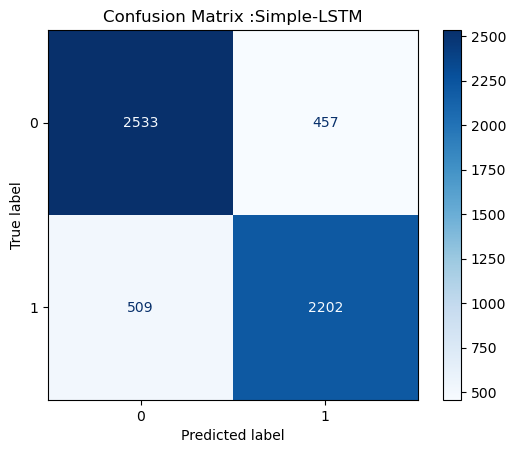

In [105]:
lstm_result=evaluation_model(lstm_model,"Simple-LSTM",X_test_pad,X_train_pad,y_test,y_train)
results2.append(lstm_result)

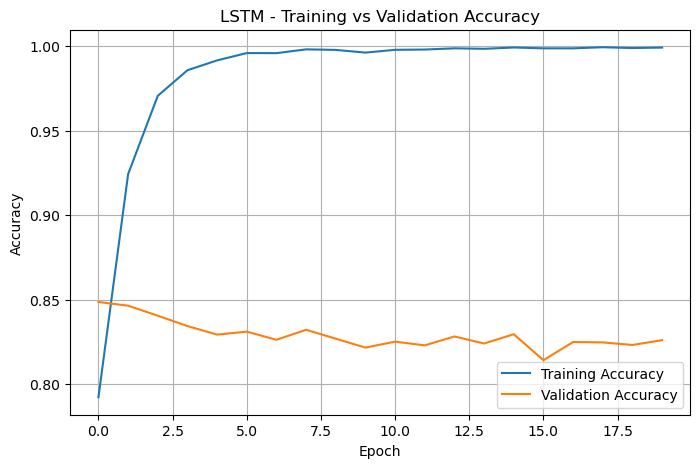

In [106]:
#Training Accurcay VS VALIDATION ACCURACY GRAPH
plt.figure(figsize=(8, 5))

plt.plot(lstm_history.history["accuracy"],label="Training Accuracy")
plt.plot(lstm_history.history["val_accuracy"],label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("LSTM - Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

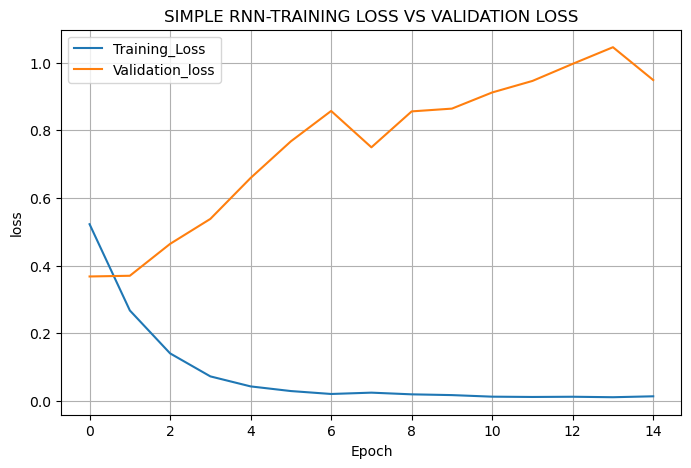

In [107]:
#Training loss VS VALIDATION loss GRAPH 

plt.figure(figsize=(8,5))

plt.plot(rnn_history.history["loss"],label="Training_Loss")
plt.plot(rnn_history.history["val_loss"],label="Validation_loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.title("SIMPLE RNN-TRAINING LOSS VS VALIDATION LOSS")
plt.legend()
plt.grid()
plt.show()

#### 3. GRU

In [108]:
#Sequential
gru_model=Sequential()

#Input 
gru_model.add(Input(shape=(MAX_LEN,)))

#Embedding Layer
gru_model.add(Embedding(input_dim=MAX_WORDS,output_dim=128,mask_zero=True))

#dropout layer
gru_model.add(SpatialDropout1D(0.2))

#Model
gru_model.add(GRU(units=64,dropout=0.2,recurrent_dropout=0.3))

#Hidden Layer
gru_model.add(Dense(units=64,activation='relu'))

#Dropout
gru_model.add(Dropout(0.3))

# Output

gru_model.add(Dense(units=1,activation='sigmoid'))

In [109]:
gru_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [110]:
gru_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 16, 128)        │     3,200,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ (None, 16, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,241,473 (12.37 MB)

 Trainable params: 3,241,473 (12.37 MB)

 Non-trainable params: 0 (0.00 B)

In [111]:
gru_history=gru_model.fit(X_train_pad,y_train,validation_split=0.2,epochs=20,batch_size=64,verbose=1)

Epoch 1/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.7774 - loss: 0.4543 - val_accuracy: 0.8511 - val_loss: 0.3503
Epoch 2/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - accuracy: 0.9194 - loss: 0.2172 - val_accuracy: 0.8467 - val_loss: 0.3658
Epoch 3/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 0.9603 - loss: 0.1116 - val_accuracy: 0.8358 - val_loss: 0.4673
Epoch 4/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - accuracy: 0.9820 - loss: 0.0542 - val_accuracy: 0.8389 - val_loss: 0.5899
Epoch 5/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.9919 - loss: 0.0271 - val_accuracy: 0.8332 - val_loss: 0.7681
Epoch 6/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - accuracy: 0.9943 - loss: 0.0163 - val_accuracy: 0.8327 - val_loss: 0.7725
Epoch 7/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.9950 - loss: 0.0149 - val_accuracy: 0.8270 - val_loss: 0.9153
Epoch 8/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - accuracy: 0.9963 - loss: 0.0126 - 

MODEL :Simple-GRU
TEST_ACCURACY:0.8299
TRAIN_ACCURACY:0.9646
RECALL :0.8366

Classification_Report

              precision    recall  f1-score   support

           0     0.8476    0.8237    0.8355      2990
           1     0.8114    0.8366    0.8238      2711

    accuracy                         0.8299      5701
   macro avg     0.8295    0.8302    0.8297      5701
weighted avg     0.8304    0.8299    0.8299      5701



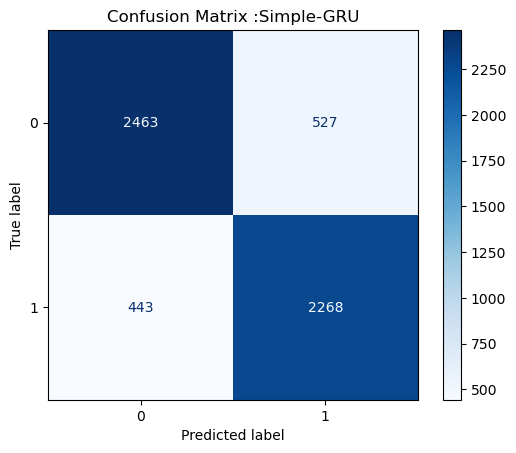

In [112]:
gru_result=evaluation_model(gru_model,"Simple-GRU",X_test_pad,X_train_pad,y_test,y_train)
results2.append(gru_result)

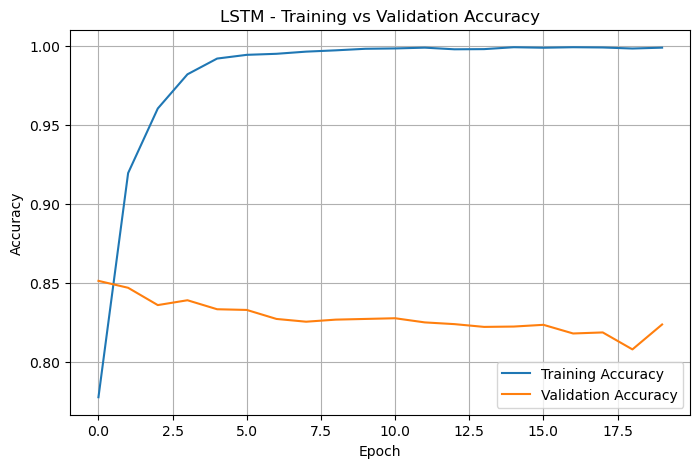

In [113]:
#Training Accurcay VS VALIDATION ACCURACY GRAPH
plt.figure(figsize=(8, 5))

plt.plot(gru_history.history["accuracy"],label="Training Accuracy")
plt.plot(gru_history.history["val_accuracy"],label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("LSTM - Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

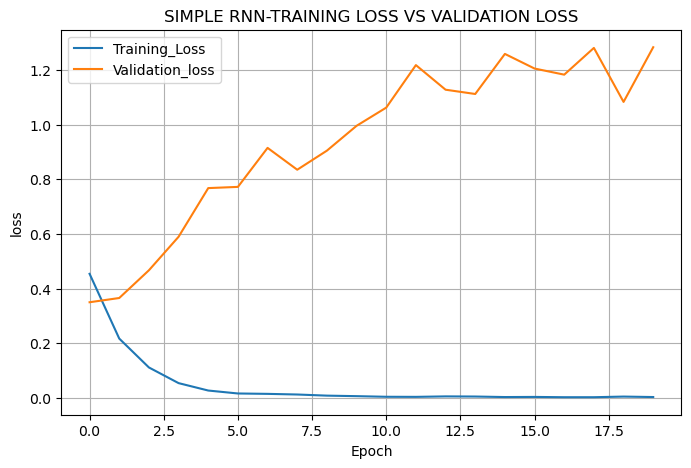

In [114]:
#Training loss VS VALIDATION loss GRAPH 

plt.figure(figsize=(8,5))

plt.plot(gru_history.history["loss"],label="Training_Loss")
plt.plot(gru_history.history["val_loss"],label="Validation_loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.title("SIMPLE RNN-TRAINING LOSS VS VALIDATION LOSS")
plt.legend()
plt.grid()
plt.show()

#### 4. BI DIRECTIONAL RNN 

In [115]:
birnn_model=Sequential()

#Input 
birnn_model.add(Input(shape=(MAX_LEN,)))

# Embedding
birnn_model.add(Embedding(input_dim=MAX_WORDS,output_dim=128,mask_zero=True))

#DROPOUT
birnn_model.add(SpatialDropout1D(0.2))

# Model Layer
birnn_model.add(Bidirectional(SimpleRNN(units=64,dropout=0.2,recurrent_dropout=0.3)))

#hidden Layer
birnn_model.add(Dense(units=64,activation='relu'))

#dropout
birnn_model.add(Dropout(0.3))

#output

birnn_model.add(Dense(units=1,activation='sigmoid'))

In [116]:
birnn_model.compile(optimizer='adam',loss="binary_crossentropy",metrics=["accuracy"])

In [117]:
birnn_history=birnn_model.fit( X_train_pad,y_train,validation_split=0.2,epochs=20,batch_size=64,verbose=1)

Epoch 1/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.6728 - loss: 0.5804 - val_accuracy: 0.8338 - val_loss: 0.3784
Epoch 2/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - accuracy: 0.8729 - loss: 0.3137 - val_accuracy: 0.8483 - val_loss: 0.3495
Epoch 3/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.9362 - loss: 0.1741 - val_accuracy: 0.8391 - val_loss: 0.3981
Epoch 4/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - accuracy: 0.9620 - loss: 0.1083 - val_accuracy: 0.8397 - val_loss: 0.4589
Epoch 5/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - accuracy: 0.9776 - loss: 0.0664 - val_accuracy: 0.8367 - val_loss: 0.5288
Epoch 6/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.9863 - loss: 0.0416 - val_accuracy: 0.8285 - val_loss: 0.6561
Epoch 7/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - accuracy: 0.9908 - loss: 0.0308 - val_accuracy: 0.8332 - val_loss: 0.8125
Epoch 8/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - accuracy: 0.9918 - loss: 0.0224 - 

MODEL :BI-RNN
TEST_ACCURACY:0.8437
TRAIN_ACCURACY:0.9662
RECALL :0.8469

Classification_Report

              precision    recall  f1-score   support

           0     0.8583    0.8408    0.8495      2990
           1     0.8283    0.8469    0.8375      2711

    accuracy                         0.8437      5701
   macro avg     0.8433    0.8439    0.8435      5701
weighted avg     0.8440    0.8437    0.8438      5701



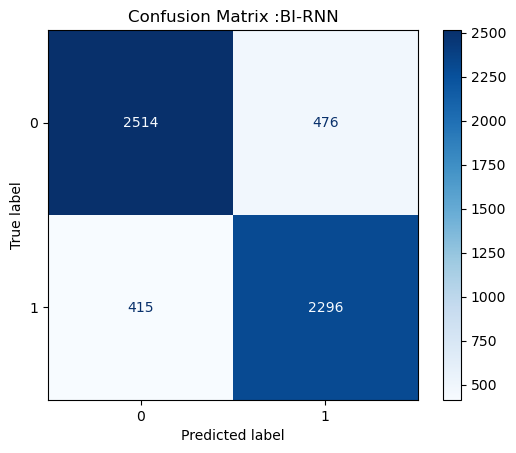

In [118]:
birnn_result=evaluation_model(birnn_model,"BI-RNN",X_test_pad,X_train_pad,y_test,y_train)
results2.append(birnn_result)

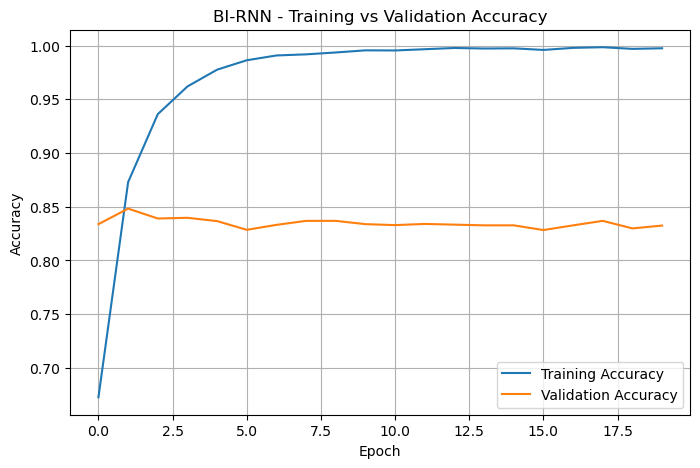

In [119]:
#Training Accurcay VS VALIDATION ACCURACY GRAPH
plt.figure(figsize=(8, 5))

plt.plot(birnn_history.history["accuracy"],label="Training Accuracy")
plt.plot(birnn_history.history["val_accuracy"],label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("BI-RNN - Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

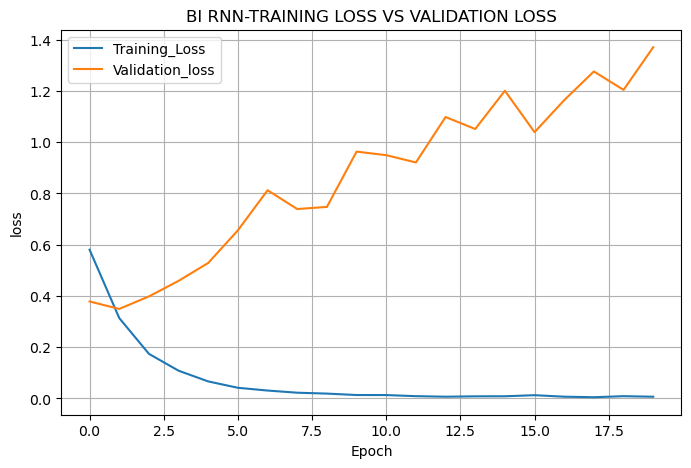

In [120]:
#Training loss VS VALIDATION loss GRAPH 

plt.figure(figsize=(8,5))

plt.plot(birnn_history.history["loss"],label="Training_Loss")
plt.plot(birnn_history.history["val_loss"],label="Validation_loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.title("BI RNN-TRAINING LOSS VS VALIDATION LOSS")
plt.legend()
plt.grid()
plt.show()

#### 5. BI-LSTM 

In [121]:
bilstm_model=Sequential()

#Input 
bilstm_model.add(Input(shape=(MAX_LEN,)))

# Embedding
bilstm_model.add(Embedding(input_dim=MAX_WORDS,output_dim=128,mask_zero=True))

#DROPOUT
bilstm_model.add(SpatialDropout1D(0.2))

# Model Layer
bilstm_model.add(Bidirectional(LSTM(units=64,dropout=0.2,recurrent_dropout=0.3)))

#hidden Layer
bilstm_model.add(Dense(units=64,activation='relu'))

#dropout
bilstm_model.add(Dropout(0.3))

#output

bilstm_model.add(Dense(units=1,activation='sigmoid'))

In [122]:
bilstm_model.compile(optimizer='adam',loss="binary_crossentropy",metrics=["accuracy"])

In [123]:
bilstm_history=bilstm_model.fit( X_train_pad,y_train,validation_split=0.2,epochs=20,batch_size=64,verbose=1)

Epoch 1/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 45s 93ms/step - accuracy: 0.8011 - loss: 0.4187 - val_accuracy: 0.8551 - val_loss: 0.3270
Epoch 2/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - accuracy: 0.9323 - loss: 0.1752 - val_accuracy: 0.8513 - val_loss: 0.3638
Epoch 3/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.9764 - loss: 0.0675 - val_accuracy: 0.8417 - val_loss: 0.4915
Epoch 4/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - accuracy: 0.9910 - loss: 0.0287 - val_accuracy: 0.8417 - val_loss: 0.5885
Epoch 5/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.9947 - loss: 0.0148 - val_accuracy: 0.8367 - val_loss: 0.7773
Epoch 6/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.9973 - loss: 0.0084 - val_accuracy: 0.8391 - val_loss: 0.8531
Epoch 7/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.9983 - loss: 0.0053 - val_accuracy: 0.8356 - val_loss: 0.9105
Epoch 8/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.9981 - loss: 0.0054 - 

MODEL :BI-LSTM
TEST_ACCURACY:0.8397
TRAIN_ACCURACY:0.9648
RECALL :0.8646

Classification_Report

              precision    recall  f1-score   support

           0     0.8694    0.8171    0.8424      2990
           1     0.8108    0.8646    0.8368      2711

    accuracy                         0.8397      5701
   macro avg     0.8401    0.8408    0.8396      5701
weighted avg     0.8415    0.8397    0.8398      5701



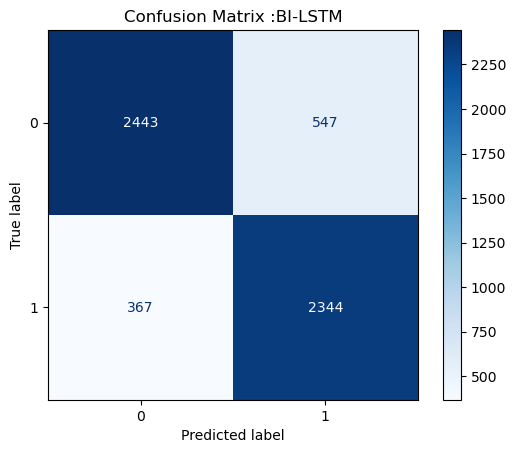

In [124]:
bilstm_result=evaluation_model(bilstm_model,"BI-LSTM",X_test_pad,X_train_pad,y_test,y_train)
results2.append(bilstm_result)

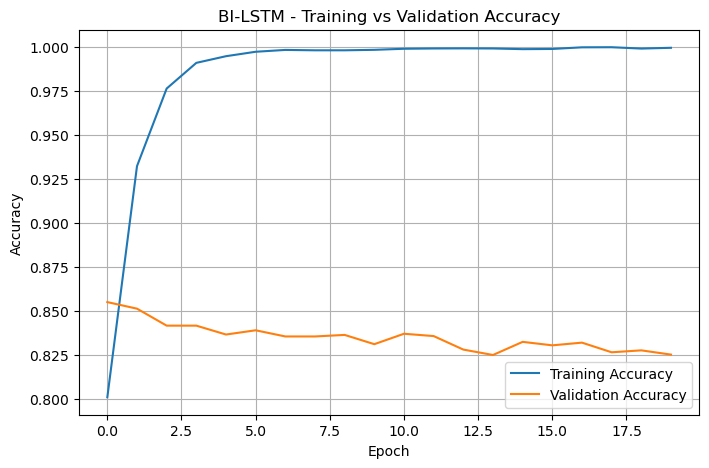

In [125]:
#Training Accurcay VS VALIDATION ACCURACY GRAPH
plt.figure(figsize=(8, 5))

plt.plot(bilstm_history.history["accuracy"],label="Training Accuracy")
plt.plot(bilstm_history.history["val_accuracy"],label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("BI-LSTM - Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

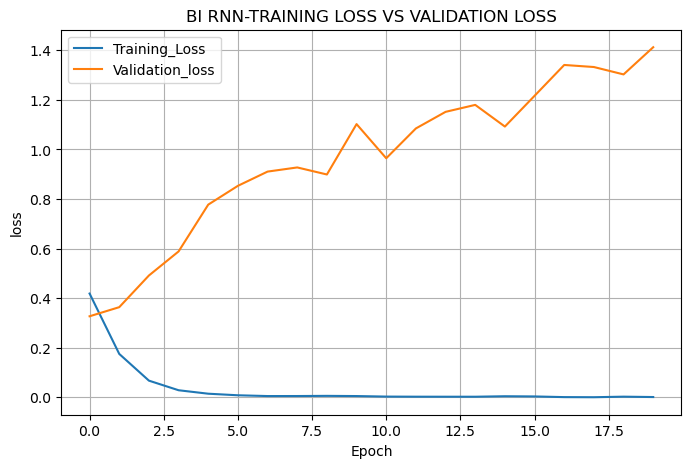

In [126]:
#Training loss VS VALIDATION loss GRAPH 

plt.figure(figsize=(8,5))

plt.plot(bilstm_history.history["loss"],label="Training_Loss")
plt.plot(bilstm_history.history["val_loss"],label="Validation_loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.title("BI RNN-TRAINING LOSS VS VALIDATION LOSS")
plt.legend()
plt.grid()
plt.show()

#### 6. BI-GRU

In [127]:
bigru_model=Sequential()

#Input 
bigru_model.add(Input(shape=(MAX_LEN,)))

# Embedding
bigru_model.add(Embedding(input_dim=MAX_WORDS,output_dim=128,mask_zero=True))

#DROPOUT
bigru_model.add(SpatialDropout1D(0.2))

# Model Layer
bigru_model.add(Bidirectional(GRU(units=64,dropout=0.2,recurrent_dropout=0.3)))

#hidden Layer
bigru_model.add(Dense(units=64,activation='relu'))

#dropout
bigru_model.add(Dropout(0.3))

#output

bigru_model.add(Dense(units=1,activation='sigmoid'))

In [128]:
bigru_model.compile(optimizer='adam',loss="binary_crossentropy",metrics=["accuracy"])

In [129]:
bigru_history=bigru_model.fit( X_train_pad,y_train,validation_split=0.2,epochs=20,batch_size=64,verbose=1)

Epoch 1/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 28s 64ms/step - accuracy: 0.8012 - loss: 0.4169 - val_accuracy: 0.8610 - val_loss: 0.3202
Epoch 2/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 17s 61ms/step - accuracy: 0.9404 - loss: 0.1606 - val_accuracy: 0.8509 - val_loss: 0.3831
Epoch 3/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - accuracy: 0.9797 - loss: 0.0612 - val_accuracy: 0.8454 - val_loss: 0.5059
Epoch 4/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.9924 - loss: 0.0231 - val_accuracy: 0.8426 - val_loss: 0.6453
Epoch 5/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step - accuracy: 0.9952 - loss: 0.0142 - val_accuracy: 0.8404 - val_loss: 0.6956
Epoch 6/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.9964 - loss: 0.0104 - val_accuracy: 0.8406 - val_loss: 0.7816
Epoch 7/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.9981 - loss: 0.0060 - val_accuracy: 0.8307 - val_loss: 0.9424
Epoch 8/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 18s 62ms/step - accuracy: 0.9986 - loss: 0.0041 - 

MODEL :BI-GRU
TEST_ACCURACY:0.8360
TRAIN_ACCURACY:0.9644
RECALL :0.8285

Classification_Report

              precision    recall  f1-score   support

           0     0.8442    0.8428    0.8435      2990
           1     0.8270    0.8285    0.8277      2711

    accuracy                         0.8360      5701
   macro avg     0.8356    0.8356    0.8356      5701
weighted avg     0.8360    0.8360    0.8360      5701



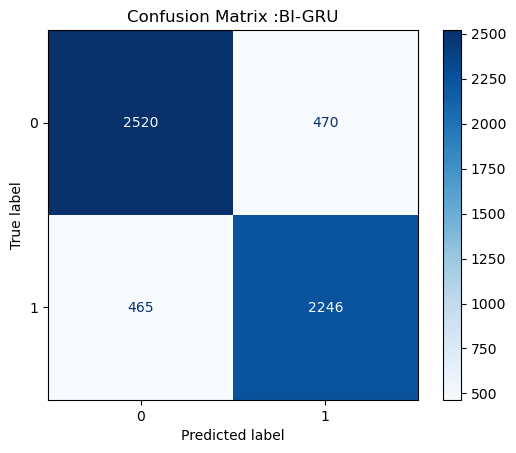

In [130]:
bigru_result=evaluation_model(bigru_model,"BI-GRU",X_test_pad,X_train_pad,y_test,y_train)
results2.append(bigru_result)

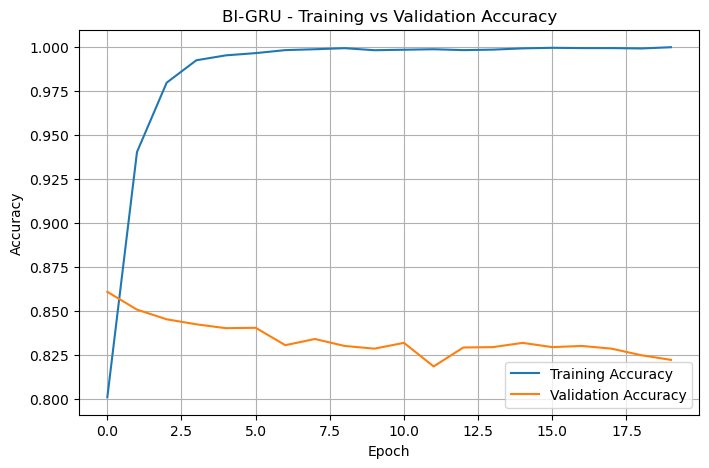

In [131]:
#Training Accurcay VS VALIDATION ACCURACY GRAPH
plt.figure(figsize=(8, 5))

plt.plot(bigru_history.history["accuracy"],label="Training Accuracy")
plt.plot(bigru_history.history["val_accuracy"],label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("BI-GRU - Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

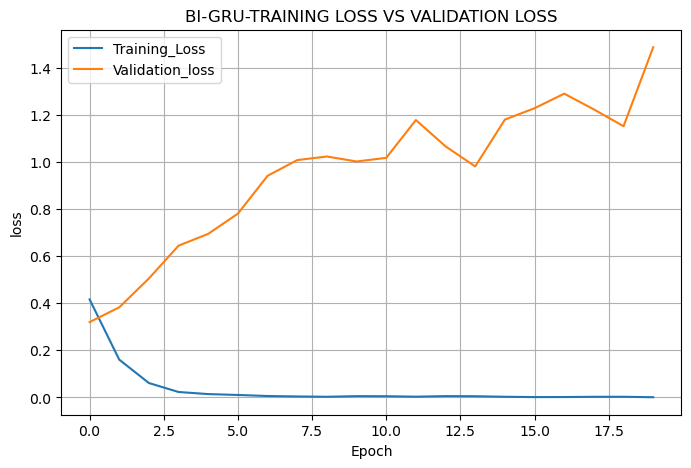

In [132]:
#Training loss VS VALIDATION loss GRAPH 

plt.figure(figsize=(8,5))

plt.plot(bigru_history.history["loss"],label="Training_Loss")
plt.plot(bigru_history.history["val_loss"],label="Validation_loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.title("BI-GRU-TRAINING LOSS VS VALIDATION LOSS")
plt.legend()
plt.grid()
plt.show()

In [133]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

### KERAS TUNER ON BI LSTM

In [134]:
def bilstm_tune(hp):
    model= Sequential()
    model.add(Input(shape=(MAX_LEN,)))
    model.add(Embedding(input_dim=MAX_WORDS,output_dim=128,mask_zero=True))
    spatial_dropout=hp.Float("spatial_dropout",min_value=0.1,max_value=0.5,step=0.1)
    model.add(SpatialDropout1D(spatial_dropout))
    lstm_units=hp.Choice("lstm_units",values=[32,64,128])
    lstm_dropout=hp.Float("lstm_dropout",min_value=0.1,max_value=0.5,step=0.1)
    model.add(Bidirectional(LSTM(units=lstm_units,dropout=lstm_dropout)))
    dense_layer=hp.Choice("Dense_units",values=[32,64,128])
    model.add(Dense(units=dense_layer,activation='relu'))
    dense_dropout=hp.Float("dense_dropout",min_value=0.1,max_value=0.5,step=0.1)
    model.add(Dropout(dense_dropout))
    model.add(Dense(1,activation="sigmoid"))

    # learning rate
    learning_rate=hp.Choice("learning_rate",values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=Adam(learning_rate=learning_rate),loss='binary_crossentropy',metrics=['accuracy'])
    return model
    

#### creating keras tuner

#### 7. TUNED- BI-DIRECTIONAL LSTM - 

In [135]:
bilstm_tuned_model=Sequential()

#Input 
bilstm_tuned_model.add(Input(shape=(MAX_LEN,)))

# Embedding
bilstm_tuned_model.add(Embedding(input_dim=MAX_WORDS,output_dim=64,mask_zero=True))

#DROPOUT
bilstm_tuned_model.add(SpatialDropout1D(0.1))

# Model Layer
bilstm_tuned_model.add(Bidirectional(LSTM(units=32,dropout=0.5,recurrent_dropout=0.3)))

#hidden Layer
bilstm_tuned_model.add(Dense(units=32,activation='relu'))

#dropout
bilstm_tuned_model.add(Dropout(0.4))

#output

bilstm_tuned_model.add(Dense(units=1,activation='sigmoid'))

In [136]:
bilstm_tuned_model.compile(optimizer=Adam(learning_rate=0.001),loss="binary_crossentropy",metrics=["accuracy"])

In [137]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping=EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True,mode='min')

In [138]:
bilstm_tuned_history=bilstm_tuned_model.fit( X_train_pad,y_train,validation_split=0.2,epochs=35,batch_size=64,callbacks=[early_stopping],verbose=1)

Epoch 1/35
286/286 ━━━━━━━━━━━━━━━━━━━━ 36s 54ms/step - accuracy: 0.7727 - loss: 0.4662 - val_accuracy: 0.8478 - val_loss: 0.3420
Epoch 2/35
286/286 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.9180 - loss: 0.2161 - val_accuracy: 0.8489 - val_loss: 0.3574
Epoch 3/35
286/286 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.9621 - loss: 0.1053 - val_accuracy: 0.8463 - val_loss: 0.4497
Epoch 4/35
286/286 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.9821 - loss: 0.0574 - val_accuracy: 0.8389 - val_loss: 0.5563


MODEL :TUNED-BI-LSTM
TEST_ACCURACY:0.8618
TRAIN_ACCURACY:0.9107
RECALL :0.8713

Classification_Report

              precision    recall  f1-score   support

           0     0.8797    0.8532    0.8662      2990
           1     0.8433    0.8713    0.8570      2711

    accuracy                         0.8618      5701
   macro avg     0.8615    0.8622    0.8616      5701
weighted avg     0.8624    0.8618    0.8619      5701



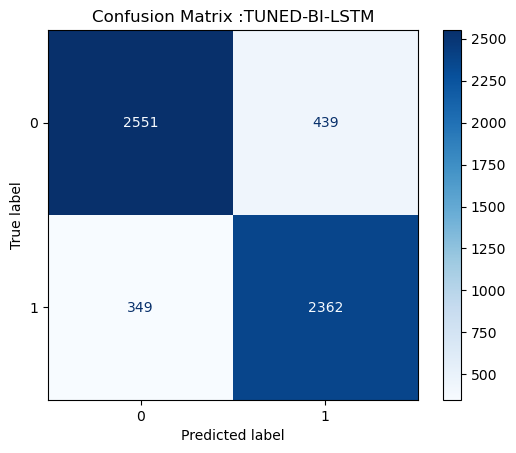

In [139]:
bilstm_tuned_result=evaluation_model(bilstm_tuned_model,"TUNED-BI-LSTM",X_test_pad,X_train_pad,y_test,y_train)
results2.append(bilstm_tuned_result)

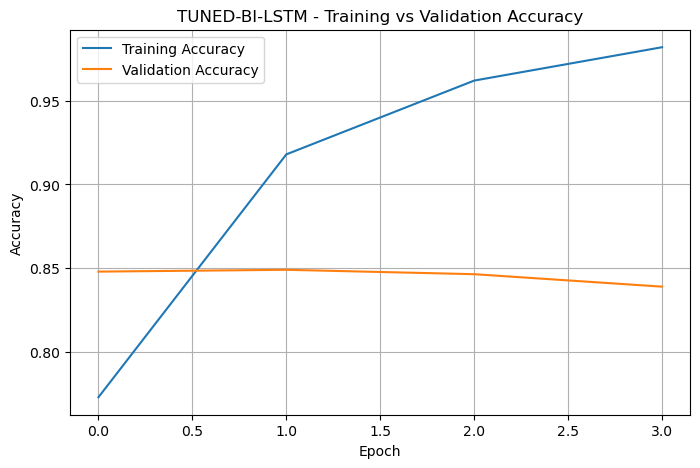

In [140]:
#Training Accurcay VS VALIDATION ACCURACY GRAPH
plt.figure(figsize=(8, 5))

plt.plot(bilstm_tuned_history.history["accuracy"],label="Training Accuracy")
plt.plot(bilstm_tuned_history.history["val_accuracy"],label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("TUNED-BI-LSTM - Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

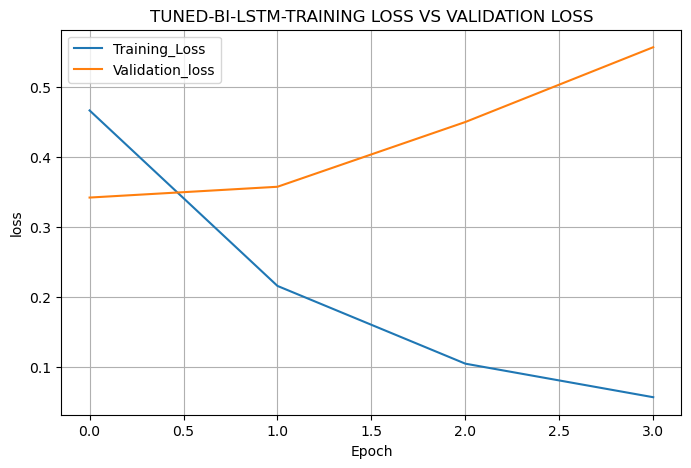

In [141]:
#Training loss VS VALIDATION loss GRAPH 

plt.figure(figsize=(8,5))

plt.plot(bilstm_tuned_history.history["loss"],label="Training_Loss")
plt.plot(bilstm_tuned_history.history["val_loss"],label="Validation_loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.title("TUNED-BI-LSTM-TRAINING LOSS VS VALIDATION LOSS")
plt.legend()
plt.grid()
plt.show()

# COMPARISION TABLE

In [142]:
r=pd.DataFrame(results2)
print(r)

           Model  Train_accuracy  Test_Accuracy    Recall
0     Simple-RNN        0.964170       0.830556  0.815197
1    Simple-LSTM        0.965222       0.830556  0.812246
2     Simple-GRU        0.964608       0.829854  0.836592
3         BI-RNN        0.966231       0.843712  0.846920
4        BI-LSTM        0.964784       0.839677  0.864626
5         BI-GRU        0.964389       0.835994  0.828477
6  TUNED-BI-LSTM        0.910710       0.861779  0.871265


In [146]:
r.style.set_properties(
    subset=pd.IndexSlice[6, :],
    **{"background-color": "lightgreen"}
)

,Model,Train_accuracy,Test_Accuracy,Recall
0,Simple-RNN,0.964170,0.830556,0.815197
1,Simple-LSTM,0.965222,0.830556,0.812246
2,Simple-GRU,0.964608,0.829854,0.836592
3,BI-RNN,0.966231,0.843712,0.846920
4,BI-LSTM,0.964784,0.839677,0.864626
5,BI-GRU,0.964389,0.835994,0.828477
6,TUNED-BI-LSTM,0.910710,0.861779,0.871265


In [162]:
!git reset HEAD~1

Unstaged changes after reset:
M	.ipynb_checkpoints/Sarcsam_NLP_DEEP_LEARNING-checkpoint.ipynb
M	Sarcsam_NLP_DEEP_LEARNING.ipynb
D	bilstm_tuned_model.keras
D	bilstm_tuned_model.weights.h5
D	tokenizer.pkl


In [163]:
!notepad .gitignore

In [164]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

Changes not staged for commit:
  (use "git add/rm <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   .ipynb_checkpoints/Sarcsam_NLP_DEEP_LEARNING-checkpoint.ipynb
	modified:   Sarcsam_NLP_DEEP_LEARNING.ipynb
	deleted:    bilstm_tuned_model.keras
	deleted:    bilstm_tuned_model.weights.h5
	deleted:    tokenizer.pkl

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.gitignore

no changes added to commit (use "git add" and/or "git commit -a")
